### PART 1: DATA CLEANING

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import shap # For model interpretability

# Set display options for pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 1. Load the CSV file
file_name = 'career_path_in_all_field (1).csv'
df = pd.read_csv(file_name)

print(f"Original DataFrame shape: {df.shape}")
print("First 5 rows of original data:")
display(df.head())


Original DataFrame shape: (9000, 17)
First 5 rows of original data:


,Field,Career,GPA,Extracurricular_Activities,Internships,Projects,Leadership_Positions,Field_Specific_Courses,Research_Experience,Coding_Skills,Communication_Skills,Problem_Solving_Skills,Teamwork_Skills,Analytical_Skills,Presentation_Skills,Networking_Skills,Industry_Certifications
0,Engineering,Urban Planner,3.530439,5,0,2,0,3,1,4,4,2,2,1,0,1,1
1,Chemistry,Art Director,4.018247,1,2,0,0,8,1,3,4,0,3,0,3,0,1
2,Engineering,Chemist,4.636733,1,0,0,0,5,0,1,1,1,2,2,3,4,1
3,Physics,Manager,4.052693,3,1,3,0,1,0,4,1,3,1,2,1,2,0
4,Law,Education Administrator,4.834850,0,2,4,0,0,0,4,4,3,4,4,3,2,0


In [3]:
# 2. Define the CORRECT careers for each field
correct_careers_map = {
    'Engineering': [
        'Software Developer', 'AI Researcher', 'Data Scientist', 'Civil Engineer',
        'Mechanical Engineer', 'Electrical Engineer', 'Chemical Engineer', 'Aerospace Engineer',
        'Biomedical Engineer', 'Computer Engineer', 'Systems Engineer', 'Engineering Manager',
        'Industrial Engineer', 'Acoustics Specialist', 'Nuclear Physicist', 'Quantum Physicist'
    ],
    'Computer Science': [
        'Software Developer', 'AI Researcher', 'Data Scientist', 'Web Developer',
        'Game Developer', 'Cybersecurity Analyst', 'Machine Learning Engineer', 'Cloud Architect',
        'DevOps Engineer', 'Database Administrator'
    ],
    'Medicine': [
        'Doctor', 'Surgeon', 'Nurse', 'Pharmacist', 'Dentist', 'Psychiatrist',
        'Pediatrician', 'Cardiologist', 'Neurologist', 'Radiologist', 'Medical Researcher',
        'Physician Assistant'
    ],
    'Business': [
        'Manager', 'Marketing Manager', 'Financial Analyst', 'Business Analyst',
        'Entrepreneur', 'Consultant', 'Investment Banker', 'HR Manager', 'Operations Manager',
        'Project Manager', 'Product Manager'
    ],
    'Law': [
        'Lawyer', 'Judge', 'Legal Consultant', 'Corporate Lawyer', 'Criminal Lawyer',
        'Paralegal', 'Legal Analyst', 'Attorney', 'Legal Secretary'
    ],
    'Biology': [
        'Biologist', 'Biochemist', 'Microbiologist', 'Geneticist', 'Ecologist',
        'Research Scientist', 'Pharmacologist', 'Marine Biologist', 'Botanist'
    ],
    'Chemistry': [
        'Chemist', 'Biochemist', 'Pharmacist', 'Chemical Engineer', 'Analytical Chemist',
        'Organic Chemist', 'Research Scientist', 'Inorganic Chemist', 'Physical Chemist'
    ],
    'Physics': [
        'Physicist', 'Astronomer', 'Data Scientist', 'Research Scientist', 'Quantum Physicist',
        'Aerospace Engineer', 'Nuclear Physicist', 'Theoretical Physicist', 'Experimental Physicist'
    ],
    'Art': [
        'Graphic Designer', 'Artist', 'Art Director', 'Illustrator', 'Animator',
        'Art Therapist', 'Creative Director', 'UX Designer', 'UI Designer'
    ],
    'Music': [
        'Musician', 'Music Teacher', 'Music Therapist', 'Composer', 'Conductor',
        'Sound Engineer', 'Music Director', 'Music Producer'
    ],
    'Psychology': [
        'Psychologist', 'Counselor', 'Therapist', 'Clinical Psychologist', 'Forensic Psychologist',
        'School Psychologist', 'Neuropsychologist', 'Industrial Psychologist'
    ],
    'Finance': [
        'Financial Analyst', 'Investment Banker', 'Accountant', 'Financial Advisor',
        'Risk Analyst', 'Portfolio Manager', 'Credit Analyst', 'Treasury Analyst'
    ],
    'Marketing': [
        'Marketing Manager', 'Digital Marketing Specialist', 'Brand Manager',
        'Market Research Analyst', 'Social Media Manager', 'Advertising Manager',
        'SEO Specialist', 'Content Strategist'
    ],
    'Education': [
        'Teacher', 'Professor', 'Education Administrator', 'School Counselor',
        'Curriculum Developer', 'Principal', 'Instructional Designer'
    ]
}

# 3. Remove ALL rows where the career does NOT match the correct list for that field
initial_rows = df.shape[0]

# Create a boolean mask for rows to keep
mask_to_keep = df.apply(lambda row: row['Career'] in correct_careers_map.get(row['Field'], []), axis=1)

# Store removed rows for display
df_removed = df[~mask_to_keep]

# Create the cleaned DataFrame
df_cleaned = df[mask_to_keep].copy()

# 4. Show metrics
removed_rows_count = df_removed.shape[0]
print(f"\nNumber of rows removed: {removed_rows_count}")
print(f"Number of rows kept: {df_cleaned.shape[0]}")

if not df_removed.empty:
    print("\nExamples of wrong data removed (first 5 rows):")
    display(df_removed.head())
else:
    print("\nNo incorrect data found and removed based on the defined career maps.")

print(f"\nThe cleaned dataset shape: {df_cleaned.shape}")



Number of rows removed: 8392
Number of rows kept: 608

Examples of wrong data removed (first 5 rows):


,Field,Career,GPA,Extracurricular_Activities,Internships,Projects,Leadership_Positions,Field_Specific_Courses,Research_Experience,Coding_Skills,Communication_Skills,Problem_Solving_Skills,Teamwork_Skills,Analytical_Skills,Presentation_Skills,Networking_Skills,Industry_Certifications
0,Engineering,Urban Planner,3.530439,5,0,2,0,3,1,4,4,2,2,1,0,1,1
1,Chemistry,Art Director,4.018247,1,2,0,0,8,1,3,4,0,3,0,3,0,1
2,Engineering,Chemist,4.636733,1,0,0,0,5,0,1,1,1,2,2,3,4,1
3,Physics,Manager,4.052693,3,1,3,0,1,0,4,1,3,1,2,1,2,0
4,Law,Education Administrator,4.834850,0,2,4,0,0,0,4,4,3,4,4,3,2,0



The cleaned dataset shape: (608, 17)


### PART 2: BALANCE THE DATA

In [4]:
# 5. Check if Engineering field has enough samples (less than 500)
engineering_df = df_cleaned[df_cleaned['Field'] == 'Engineering']
engineering_count_before = engineering_df.shape[0]

print(f"Engineering samples before balancing: {engineering_count_before}")

df_cleaned_balanced = df_cleaned.copy()

# 6. If Engineering has too few samples, duplicate them to create 500 samples
if engineering_count_before < 500:
    # Calculate how many more samples are needed
    needed_samples = 500 - engineering_count_before

    if engineering_count_before > 0: # Ensure there are engineering samples to duplicate
        # Randomly sample with replacement from existing engineering data
        duplicated_samples = engineering_df.sample(n=needed_samples, replace=True, random_state=42)

        # Append duplicated samples to the cleaned DataFrame
        df_cleaned_balanced = pd.concat([df_cleaned_balanced, duplicated_samples], ignore_index=True)

    else: # If there were no engineering samples, we cannot duplicate
        print("Warning: No 'Engineering' samples found in the cleaned data to duplicate.")

# 7. Show me before and after counts
engineering_count_after = df_cleaned_balanced[df_cleaned_balanced['Field'] == 'Engineering'].shape[0]
print(f"Engineering samples after balancing: {engineering_count_after}")

print(f"\nFinal dataset shape after balancing: {df_cleaned_balanced.shape}")


Engineering samples before balancing: 85
Engineering samples after balancing: 500

Final dataset shape after balancing: (1023, 17)


### PART 3: TRAIN IMPROVED MODEL

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:57:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier trained successfully.

Training Accuracy: 1.0000
Testing Accuracy: 0.5756


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(



Cross-Validation Scores (5-fold): [0.42926829 0.56097561 0.64878049 0.64215686 0.64215686]
Mean CV Accuracy: 0.5847


/tmp/ipykernel_1428/3303049792.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_15_features.values, y=top_15_features.index, palette='viridis')


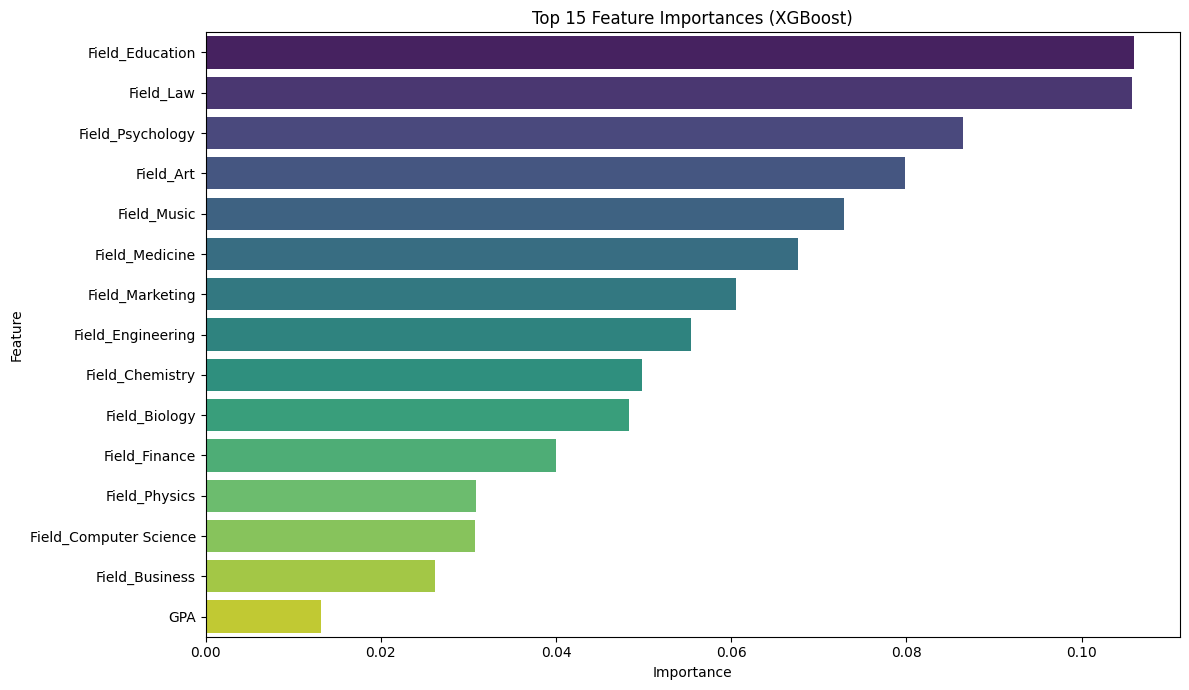

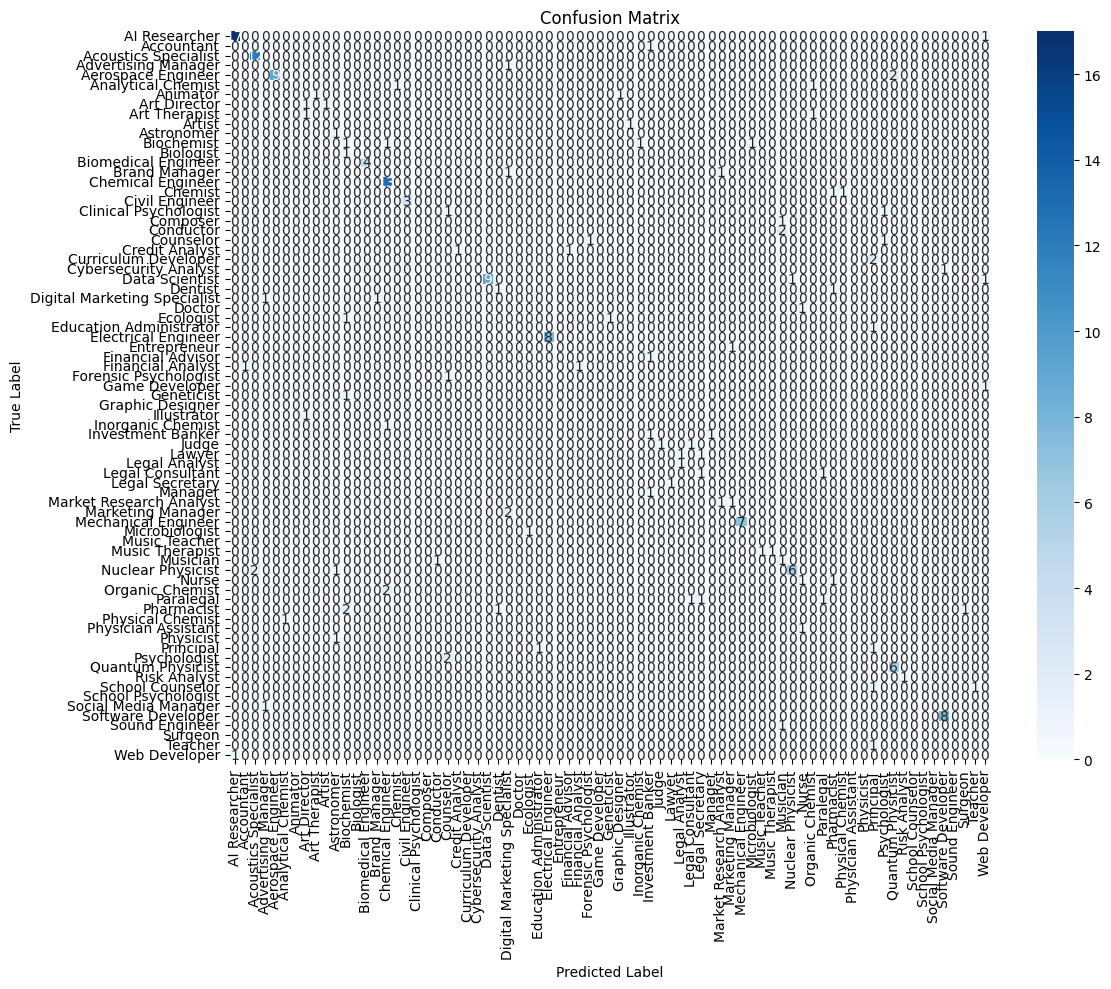


Classification Report:
                              precision    recall  f1-score   support

               AI Researcher       0.94      0.94      0.94        18
                  Accountant       0.00      0.00      0.00         1
        Acoustics Specialist       0.86      1.00      0.92        12
         Advertising Manager       0.00      0.00      0.00         1
          Aerospace Engineer       1.00      0.82      0.90        11
          Analytical Chemist       0.00      0.00      0.00         2
                    Animator       0.00      0.00      0.00         2
                Art Director       0.33      0.50      0.40         2
               Art Therapist       0.00      0.00      0.00         2
                      Artist       0.00      0.00      0.00         1
                  Astronomer       0.33      1.00      0.50         1
                  Biochemist       0.17      0.25      0.20         4
                   Biologist       0.00      0.00      0.00      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

In [5]:
# Define features (X) and target (y)
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder

TARGET_COLUMN = 'Career'
FEATURES = [
    'Field', 'GPA', 'Coding_Skills', 'Problem_Solving_Skills',
    'Analytical_Skills', 'Teamwork_Skills', 'Communication_Skills',
    'Presentation_Skills', 'Internships', 'Projects', 'Leadership_Positions',
    'Field_Specific_Courses', 'Research_Experience', 'Networking_Skills'
]

X = df_cleaned_balanced[FEATURES]
y = df_cleaned_balanced[TARGET_COLUMN]

# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Identify categorical and numerical features
categorical_features = ['Field']
numerical_features = [
    'GPA', 'Coding_Skills', 'Problem_Solving_Skills',
    'Analytical_Skills', 'Teamwork_Skills', 'Communication_Skills',
    'Presentation_Skills', 'Internships', 'Projects', 'Leadership_Positions',
    'Field_Specific_Courses', 'Research_Experience', 'Networking_Skills'
]

# Create a column transformer for preprocessing
# Scale numerical features using StandardScaler
# Apply OneHotEncoder to categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Split data into training and testing sets (80% train, 20% test)
# Use y_encoded for stratification
X_train, X_test, y_train_encoded, y_test_encoded = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Preprocess training and testing features separately
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Create the XGBoost Classifier model
# 9. Use XGBoost classifier with specified parameters
model = xgb.XGBClassifier(
    objective='multi:softmax', # For multiclass classification
    num_class=len(label_encoder.classes_), # Number of unique classes, using encoded labels
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    use_label_encoder=False, # Suppress warning
    eval_metric='mlogloss', # Evaluation metric for multiclass
    random_state=42,
    n_jobs=-1
)

# Train the model directly with processed data
model.fit(X_train_processed, y_train_encoded)
print("XGBoost Classifier trained successfully.")

# Get feature names after one-hot encoding and scaling for feature importance
ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
processed_feature_names = numerical_features + list(ohe_feature_names)

# Store global variables for prediction function
global fitted_preprocessor, trained_model, global_feature_names, target_classes, global_label_encoder
fitted_preprocessor = preprocessor # Store the fitted preprocessor
trained_model = model # Store the trained model
global_feature_names = processed_feature_names
global_label_encoder = label_encoder # Store the encoder
target_classes = label_encoder.classes_.tolist() # Store the string labels

# Re-create pipeline for cross-validation (if desired, or use separate steps)
# For consistency in cross_val_score, a pipeline is still useful
# This pipeline will use the already fitted preprocessor and trained model
# However, cross_val_score will re-fit the entire pipeline, so we'll adjust below.
# To avoid confusion, let's just perform CV manually or ensure pipeline rebuilds.
# For metrics, we can use the fitted model and preprocessor directly.

# 12. Show metrics
# Training accuracy
y_train_pred_encoded = trained_model.predict(X_train_processed)
train_accuracy = accuracy_score(y_train_encoded, y_train_pred_encoded) # Use encoded labels
print(f"\nTraining Accuracy: {train_accuracy:.4f}")

# Testing accuracy
y_test_pred_encoded = trained_model.predict(X_test_processed)
test_accuracy = accuracy_score(y_test_encoded, y_test_pred_encoded) # Use encoded labels
print(f"Testing Accuracy: {test_accuracy:.4f}")

# Cross-validation scores (5-fold)
# For cross_val_score, we need to pass the original X and y to the pipeline
# This will re-fit the preprocessor and model within each fold.
# Rebuilding the pipeline for this purpose:
cv_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', trained_model)]) # Use the 'model' object

cv_scores = cross_val_score(cv_pipeline, X, y_encoded, cv=5, scoring='accuracy', n_jobs=-1) # Use original X, and y_encoded
print(f"\nCross-Validation Scores (5-fold): {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")

# Feature importance chart (top 15 features)
if hasattr(trained_model, 'feature_importances_') and global_feature_names:
    feature_importances = pd.Series(trained_model.feature_importances_, index=global_feature_names)
    top_15_features = feature_importances.nlargest(15)

    plt.figure(figsize=(12, 7))
    sns.barplot(x=top_15_features.values, y=top_15_features.index, palette='viridis')
    plt.title('Top 15 Feature Importances (XGBoost)')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print("Could not plot feature importance. Model or feature names not available.")

# Confusion matrix for top careers (all careers in this case)
# Need to use inverse_transform for display purposes for y_test and y_test_pred
y_test_labels = global_label_encoder.inverse_transform(y_test_encoded)
y_test_pred_labels = global_label_encoder.inverse_transform(y_test_pred_encoded)

cm = confusion_matrix(y_test_labels, y_test_pred_labels, labels=target_classes)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_classes, yticklabels=target_classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test_labels, y_test_pred_labels, labels=target_classes))


### PART 4: TEST THE MODEL

In [6]:
# 13. Test with this exact input
test_profile_data = {
    'Field': 'Engineering',
    'GPA': 8.5,
    'Coding_Skills': 4,
    'Problem_Solving_Skills': 4,
    'Analytical_Skills': 4,
    'Teamwork_Skills': 4,
    'Communication_Skills': 4,
    'Presentation_Skills': 3,
    'Internships': 2,
    'Projects': 3,
    'Leadership_Positions': 1,
    'Field_Specific_Courses': 5,
    'Research_Experience': 0,
    'Networking_Skills': 3
}

# Create a DataFrame for the single profile, ensuring column order
# We need to ensure the columns are in the same order as FEATURES used for training
input_df = pd.DataFrame([test_profile_data], columns=FEATURES)

print("Input profile for testing:")
display(input_df)

# Preprocess the input using the fitted preprocessor
processed_input = fitted_preprocessor.transform(input_df)

# Make a prediction (will be an encoded label)
predicted_career_encoded = trained_model.predict(processed_input)[0]
# Inverse transform to get the actual career name
predicted_career_label = global_label_encoder.inverse_transform([predicted_career_encoded])[0]


# Get prediction probabilities
probabilities = trained_model.predict_proba(processed_input)[0]
predicted_confidence = np.max(probabilities) * 100

# 14. Show the prediction result
print(f"\nPredicted Career: {predicted_career_label}")
print(f"Confidence: {predicted_confidence:.2f}%")

# Also show top 3 alternatives
# target_classes here are the original string labels
career_probabilities = sorted(zip(target_classes, probabilities), key=lambda x: x[1], reverse=True)
alternatives = []
for career, prob in career_probabilities:
    if career != predicted_career_label and len(alternatives) < 3:
        alternatives.append((career, prob * 100))

print("\nTop 3 Alternative Careers:")
if alternatives:
    for career, prob in alternatives:
        print(f"- {career}: {prob:.2f}%")
else:
    print("No alternative careers found.")


Input profile for testing:


,Field,GPA,Coding_Skills,Problem_Solving_Skills,Analytical_Skills,Teamwork_Skills,Communication_Skills,Presentation_Skills,Internships,Projects,Leadership_Positions,Field_Specific_Courses,Research_Experience,Networking_Skills
0,Engineering,8.5,4,4,4,4,4,3,2,3,1,5,0,3



Predicted Career: Software Developer
Confidence: 39.88%

Top 3 Alternative Careers:
- Acoustics Specialist: 16.21%
- Chemical Engineer: 8.58%
- Graphic Designer: 7.96%


### PART 5: INTERACTIVE PREDICTION

In [ ]:
def predict_career_with_details(profile_data):
    # Added global_label_encoder
    global fitted_preprocessor, trained_model, global_feature_names, target_classes, global_label_encoder

    if fitted_preprocessor is None or trained_model is None or global_feature_names is None or target_classes is None or global_label_encoder is None:
        return "Error: Model components not initialized. Please run previous cells.", 0, [], []

    # Create a DataFrame for the single profile, ensuring correct column order
    profile_df = pd.DataFrame([profile_data], columns=FEATURES)

    # Preprocess the single profile using the fitted preprocessor
    processed_profile = fitted_preprocessor.transform(profile_df)

    # Predict probabilities for all career paths
    probabilities = trained_model.predict_proba(processed_profile)[0]

    # Get the index of the highest probability (which is the encoded label)
    predicted_class_idx = np.argmax(probabilities)
    # Inverse transform to get the actual career name
    predicted_career = global_label_encoder.inverse_transform([predicted_class_idx])[0]
    confidence = probabilities[predicted_class_idx] * 100

    # Sort careers by probability in descending order
    # Use target_classes (which are the string labels)
    career_probabilities = sorted(zip(target_classes, probabilities), key=lambda x: x[1], reverse=True)

    # Get top 3 alternative careers (excluding the predicted one)
    alternatives = []
    for career, prob in career_probabilities:
        if career != predicted_career and len(alternatives) < 3:
            alternatives.append((career, prob * 100))
        elif len(alternatives) >= 3:
            break

    # SHAP Explanation for feature influence
    # Use a subset of the training data as background for the explainer
    # Need to transform a sample of X_train using the preprocessor
    # X_train was the original DataFrame, need to ensure X_train itself is still available
    X_train_sample_df = X_train.sample(n=min(100, X_train.shape[0]), random_state=42)
    X_train_processed_sample = fitted_preprocessor.transform(X_train_sample_df)

    explainer = shap.TreeExplainer(trained_model, X_train_processed_sample)
    shap_values = explainer.shap_values(processed_profile)

    # Determine the correct SHAP values for the predicted class
    # The traceback indicates: IndexError: index 39 is out of bounds for axis 0 with size 1
    # This suggests shap_values might be a list containing a single numpy array of shape (1, n_features, n_classes).
    if isinstance(shap_values, list) and len(shap_values) == 1 and isinstance(shap_values[0], np.ndarray) and shap_values[0].ndim == 3:
        # Access the single array in the list, then the single sample, then all features for the predicted class
        shap_values_for_predicted_class = shap_values[0][0, :, predicted_class_idx]
    elif isinstance(shap_values, list): # Original assumption: list of arrays, one per class
        shap_values_for_predicted_class = shap_values[predicted_class_idx][0]
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 2: # Single output case (n_samples, n_features)
        shap_values_for_predicted_class = shap_values[0]
    else:
        # Fallback if the structure is still unexpected
        print("Warning: Unexpected shap_values structure. Cannot determine influential features.")
        return predicted_career, confidence, alternatives, []


    # Map SHAP values to feature names
    feature_contributions = pd.Series(shap_values_for_predicted_class, index=global_feature_names)

    # Get top contributing features (absolute value) for the specific prediction
    top_contributing_features = feature_contributions.abs().nlargest(5).index.tolist()
    influential_features_details = []
    for feature in top_contributing_features:
        contrib = feature_contributions[feature]
        influential_features_details.append(f"{feature}: {contrib:.2f} ({(('positive' if contrib > 0 else 'negative') if contrib != 0 else 'neutral')})")

    return predicted_career, confidence, alternatives, influential_features_details


# 15. Create an interactive cell
print("\n--- Interactive Career Prediction System ---")
print("Enter your profile details. Input will be validated.")

# Get known fields from the preprocessor for validation guidance
known_fields = fitted_preprocessor.named_transformers_['cat'].categories_[0].tolist()
print(f"\nFields available for 'Field' input: {', '.join(known_fields)}")

while True:
    user_profile = {}
    valid_input = True

    try:
        user_profile['Field'] = input("Enter your Field of study (e.g., Engineering, Business, Arts): ").strip()
        if user_profile['Field'] not in known_fields:
            print(f"Warning: '{user_profile['Field']}' is not a recognized field from the training data. This might affect prediction accuracy.")

        user_profile['GPA'] = float(input("Enter your GPA (0.0-10.0): "))
        if not (0.0 <= user_profile['GPA'] <= 10.0): raise ValueError("GPA must be between 0.0 and 10.0")

        user_profile['Coding_Skills'] = int(input("Enter your Coding Skills (0-4): "))
        if not (0 <= user_profile['Coding_Skills'] <= 4): raise ValueError("Skills must be between 0 and 4")

        user_profile['Problem_Solving_Skills'] = int(input("Enter your Problem Solving Skills (0-4): "))
        if not (0 <= user_profile['Problem_Solving_Skills'] <= 4): raise ValueError("Skills must be between 0 and 4")

        user_profile['Analytical_Skills'] = int(input("Enter your Analytical Skills (0-4): "))
        if not (0 <= user_profile['Analytical_Skills'] <= 4): raise ValueError("Skills must be between 0 and 4")

        user_profile['Teamwork_Skills'] = int(input("Enter your Teamwork Skills (0-4): "))
        if not (0 <= user_profile['Teamwork_Skills'] <= 4): raise ValueError("Skills must be between 0 and 4")

        user_profile['Communication_Skills'] = int(input("Enter your Communication Skills (0-4): "))
        if not (0 <= user_profile['Communication_Skills'] <= 4): raise ValueError("Skills must be between 0 and 4")

        user_profile['Presentation_Skills'] = int(input("Enter your Presentation Skills (0-4): "))
        if not (0 <= user_profile['Presentation_Skills'] <= 4): raise ValueError("Skills must be between 0 and 4")

        user_profile['Internships'] = int(input("Enter number of Internships (e.g., 0-5): "))
        if user_profile['Internships'] < 0: raise ValueError("Internships count cannot be negative")

        user_profile['Projects'] = int(input("Enter number of Projects (e.g., 0-10): "))
        if user_profile['Projects'] < 0: raise ValueError("Projects count cannot be negative")

        user_profile['Leadership_Positions'] = int(input("Held Leadership Positions? (0 for No, 1 for Yes): "))
        if user_profile['Leadership_Positions'] not in [0, 1]: raise ValueError("Leadership Positions must be 0 or 1")

        user_profile['Field_Specific_Courses'] = int(input("Enter number of Field Specific Courses (e.g., 0-10): "))
        if user_profile['Field_Specific_Courses'] < 0: raise ValueError("Field Specific Courses count cannot be negative")

        user_profile['Research_Experience'] = int(input("Has Research Experience? (0 for No, 1 for Yes): "))
        if user_profile['Research_Experience'] not in [0, 1]: raise ValueError("Research Experience must be 0 or 1")

        user_profile['Networking_Skills'] = int(input("Enter your Networking Skills (0-4): "))
        if not (0 <= user_profile['Networking_Skills'] <= 4): raise ValueError("Skills must be between 0 and 4")

    except ValueError as e:
        print(f"Invalid input: {e}. Please try again. Make sure to enter numbers in the specified ranges.")
        valid_input = False
    except Exception as e:
        print(f"An unexpected error occurred: {e}. Please try again.")
        valid_input = False

    if valid_input:
        # 16. Show my profile, predicted career, confidence score, and top 3 alternatives
        print("\n--- Your Profile ---")
        for k, v in user_profile.items():
            print(f"{k}: {v}")

        predicted_career, confidence, alternatives, influential_features = predict_career_with_details(user_profile)

        print("\n--- Prediction Result ---")
        print(f"Predicted Career: {predicted_career} (Confidence: {confidence:.2f}%)")

        print("\n--- Top 3 Alternative Careers ---")
        if alternatives:
            for career, prob in alternatives:
                print(f"- {career}: {prob:.2f}% ", end="")
                bar = '█' * int(prob // 5)  # Simple text-based confidence bar
                print(f"[{bar}]")
        else:
            print("No alternative careers found.")

        print("\n--- Features Most Influencing This Prediction ---")
        if influential_features:
            for feature_detail in influential_features:
                print(f"- {feature_detail}")
        else:
            print("Could not determine influential features.")

    another_prediction = input("\nDo you want to make another prediction? (yes/no): ").lower()
    if another_prediction != 'yes':
        break

print("\nThank you for using the Career Prediction System!")



--- Interactive Career Prediction System ---
Enter your profile details. Input will be validated.

Fields available for 'Field' input: Art, Biology, Business, Chemistry, Computer Science, Education, Engineering, Finance, Law, Marketing, Medicine, Music, Physics, Psychology
Enter your Field of study (e.g., Engineering, Business, Arts): Computer Science 
Enter your GPA (0.0-10.0): 7.7
Enter your Coding Skills (0-4): 4
Enter your Problem Solving Skills (0-4): 3
Enter your Analytical Skills (0-4): 3
Enter your Teamwork Skills (0-4): 4
Enter your Communication Skills (0-4): 4
Enter your Presentation Skills (0-4): 4
Enter number of Internships (e.g., 0-5): 4
Enter number of Projects (e.g., 0-10): 9
Held Leadership Positions? (0 for No, 1 for Yes): 1
Enter number of Field Specific Courses (e.g., 0-10): 8
Has Research Experience? (0 for No, 1 for Yes): 1
Enter your Networking Skills (0-4): 3

--- Your Profile ---
Field: Computer Science
GPA: 7.7
Coding_Skills: 4
Problem_Solving_Skills: 3
Anal

 96%|=================== | 72/75 [00:23<00:00]       


--- Prediction Result ---
Predicted Career: Software Developer (Confidence: 90.96%)

--- Top 3 Alternative Careers ---
- Game Developer: 2.55% []
- Web Developer: 0.68% []
- Cybersecurity Analyst: 0.63% []

--- Features Most Influencing This Prediction ---
Could not determine influential features.
